# Proyecto Final: Localización óptima de supermercados (Google Colab)

**Proyecto (Optimización Industrial):** elegir **10** ubicaciones entre **60** candidatos maximizando población atendida (500 m) y suma de distancias entre pares, con **distancia mínima ≥ 1 km** entre cualquier par.

# Integrantes

*   HUANACO MEDINA, JHON
*   RAMÍREZ UCAÑAY, BARBARITA PAULA JANETH
*   UGAZ PERALES, CARLOS ANDRÉ
*   VILLA LONGA , JOSE AARON


### Librerías estándar (primera celda de código)

- **`import os`** — Operaciones con el sistema de archivos: unir rutas (`os.path.join`), crear carpetas (`makedirs`) y construir rutas de salida en Colab.
- **`import json`** — Serializar y guardar resultados estructurados (por ejemplo `metricas_globales.json`) y, en el código, empaquetar listas de índices o IDs en texto para los CSV.
- **`import math`** — Funciones matemáticas para la distancia **Haversine** y trigonometría en radianes (`radians`, `sin`, `cos`, `sqrt`, etc.).
- **`import time`** — Medir el tiempo de ejecución del pipeline experimental (`time.time()` antes y después del bloque principal).
- **`from dataclasses import dataclass`** — Decorador `@dataclass` para definir de forma compacta las clases de individuos evolutivos (`MonoIndividual`, `NSGAIndividual`) con campos tipados.
- **`from typing import Tuple`** — Anotaciones de tipo para firmas de funciones (por ejemplo coordenadas o pares de objetivos), mejora la legibilidad y el autocompletado en el editor.

### Ciencia de datos y visualización

- **`import numpy as np`** — Arreglos numéricos, álgebra vectorial y generación de números aleatorios reproducibles (`np.random`) usados en operadores genéticos y matrices de distancias.
- **`import pandas as pd`** — Tablas (`DataFrame`): lectura del Excel de candidatos, exportación de CSV de resultados y manipulación de columnas en el análisis.
- **`import matplotlib.pyplot as plt`** — Gráficos de convergencia del AG, frentes de Pareto y figuras guardadas en PNG.

### Entorno Jupyter / Colab

- **`from IPython.display import display, Image, Markdown`** — **`display`** muestra tablas y objetos de pandas; **`Image`** incrusta PNG; **`Markdown`** permite títulos breves al revisar figuras en bloques de resultados.


In [1]:
import os
import json
import math
import time
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

In [2]:
!pip -q install openpyxl

In [3]:
BASE_DIR = "/content/Trabajo final"
DATA_PATH = "/content/Candidatos_supermercados.xlsx"

RESULTS_MONO_DIR = os.path.join(BASE_DIR, "resultados", "mono")
RESULTS_NSGA_DIR = os.path.join(BASE_DIR, "resultados", "nsga2")
FIG_DIR = os.path.join(BASE_DIR, "resultados", "figuras")
DATA_OUT_DIR = os.path.join(BASE_DIR, "data")

for p in [RESULTS_MONO_DIR, RESULTS_NSGA_DIR, FIG_DIR, DATA_OUT_DIR]:
    os.makedirs(p, exist_ok=True)

BASE_DIR, DATA_PATH

('/content/Trabajo final', '/content/Candidatos_supermercados.xlsx')

### Parámetros del problema y de los algoritmos

- **`K_SUPERMARKETS = 10`** — Número de ubicaciones a elegir (cardinalidad fija del cromosoma: exactamente 10 genes en `1`).
- **`MIN_DISTANCE_KM = 1.0`** — Distancia mínima entre **cualquier par** de supermercados seleccionados; define la restricción espacial dura del enunciado.
- **`POP_SIZE = 100`** — Tamaño de la población en AG mono y en NSGA-II.
- **`GENERATIONS = 500`** — Número de generaciones evolutivas por réplica (pasos de búsqueda; en otras celdas puede aparecer como `EPOCHS`).
- **`RUNS = 10`** — Número de réplicas independientes con semillas distintas (robustez estadística; puede alinearse con `REPLICAS`).
- **`PMUT = 0.25`** — Probabilidad de aplicar mutación (swap) a un individuo tras el cruce.
- **`ALPHA` / `BETA` (`0.6` / `0.4`)** — Pesos del fitness escalar en el AG mono-objetivo: balance entre población atendida normalizada y dispersión (distancias) normalizada.
- **`np.random.seed(1234)`** — Semilla base para reproducibilidad de partes del código que usan NumPy (las réplicas suelen fijar semillas adicionales por corrida).

### Geometría y datos

- **`haversine_km(...)`** — Calcula la distancia geodésica en **km** entre dos puntos `(lat, lon)` sobre la esfera terrestre (radio `6371` km). Es la métrica usada para la matriz de distancias y para comprobar el mínimo de 1 km entre pares seleccionados.
- **`load_data(path)`** — Lee el Excel en la hoja **`Hoja3`**, renombra `Poblacion500m` → `Poblacion` y convierte latitud, longitud y población a `float` para cálculos consistentes.
- **`build_distance_matrix(df)`** — Construye una matriz simétrica `n×n` con la distancia Haversine entre todos los candidatos (`i < j` y copia en `j,i`), evitando recomputar distancias en cada evaluación de factibilidad.

### Codificación y factibilidad

- **`selected_indices(chrom)`** — A partir del vector binario `chrom`, devuelve la lista de índices donde el gen vale `1` (candidatos elegidos).
- **`is_feasible(chrom, dist_mat, ...)`** — Comprueba si la solución es **válida**: exactamente **`k`** unos y, para todo par de índices seleccionados, distancia en la matriz **≥ `min_d`** km. Se usa tras reparación y para validar individuos exportados.


In [4]:
K_SUPERMARKETS = 10
MIN_DISTANCE_KM = 1.0
POP_SIZE = 100
GENERATIONS = 500
RUNS = 10
PMUT = 0.25
ALPHA = 0.6
BETA = 0.4

np.random.seed(1234)


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))


def load_data(path: str):
    df = pd.read_excel(path, sheet_name="Hoja3")
    df = df.rename(columns={"Poblacion500m": "Poblacion"})
    df["Latitud"] = df["Latitud"].astype(float)
    df["Longitud"] = df["Longitud"].astype(float)
    df["Poblacion"] = df["Poblacion"].astype(float)
    return df


def build_distance_matrix(df):
    n = len(df)
    mat = np.zeros((n, n), dtype=float)
    coords = df[["Latitud", "Longitud"]].values
    for i in range(n):
        for j in range(i + 1, n):
            d = haversine_km(coords[i, 0], coords[i, 1], coords[j, 0], coords[j, 1])
            mat[i, j] = d
            mat[j, i] = d
    return mat


def selected_indices(chrom):
    return np.where(chrom == 1)[0].tolist()


def is_feasible(chrom, dist_mat, k=K_SUPERMARKETS, min_d=MIN_DISTANCE_KM):
    idx = selected_indices(chrom)
    if len(idx) != k:
        return False
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            if dist_mat[idx[i], idx[j]] < min_d:
                return False
    return True

## Algoritmos evolutivos y experimento



### Reparación de factibilidad (`repair`)

Garantiza exactamente **10** genes en `1`. Si hay pares seleccionados a **menos de 1 km**, elimina el de **menor población** e intenta insertar otro candidato factible (máxima población entre los viables). Repite hasta corregir o agotar iteraciones.


In [5]:
def repair(chrom, populations, dist_mat, rng, k=K_SUPERMARKETS, min_d=MIN_DISTANCE_KM):
    c = chrom.copy()
    idx = selected_indices(c)
    if len(idx) > k:
        remove = rng.choice(idx, size=len(idx) - k, replace=False)
        c[remove] = 0
    elif len(idx) < k:
        not_sel = np.where(c == 0)[0]
        add = rng.choice(not_sel, size=k - len(idx), replace=False)
        c[add] = 1
    changed = True
    it = 0
    while changed and it < 500:
        changed = False
        it += 1
        idx = selected_indices(c)
        pair_violation = None
        for i in range(len(idx)):
            for j in range(i + 1, len(idx)):
                if dist_mat[idx[i], idx[j]] < min_d:
                    pair_violation = (idx[i], idx[j])
                    break
            if pair_violation is not None:
                break
        if pair_violation is not None:
            a, b = pair_violation
            rem = a if populations[a] <= populations[b] else b
            c[rem] = 0
            idx_after = selected_indices(c)
            candidates = np.where(c == 0)[0]
            feasible_cands = []
            for cand in candidates:
                ok = True
                for s in idx_after:
                    if dist_mat[cand, s] < min_d:
                        ok = False
                        break
                if ok:
                    feasible_cands.append(cand)
            if feasible_cands:
                score = np.array([populations[x] for x in feasible_cands], dtype=float)
                best = feasible_cands[int(np.argmax(score))]
                c[best] = 1
            else:
                c[rem] = 1
            changed = True
    idx = selected_indices(c)
    if len(idx) > k:
        remove = rng.choice(idx, size=len(idx) - k, replace=False)
        c[remove] = 0
    elif len(idx) < k:
        not_sel = np.where(c == 0)[0]
        add = rng.choice(not_sel, size=k - len(idx), replace=False)
        c[add] = 1
    return c




### Objetivos, fitness escalar y clases de individuo

- **`evaluate_components`**: suma de población atendida y suma de distancias entre todos los pares de elegidos.
- **`mono_fitness`**: combina ambos con `ALPHA` y `BETA` usando denominadores de normalización.
- **`MonoIndividual` / `NSGAIndividual`**: cromosoma + fitness (mono) u objetivos, rango y crowding (NSGA-II).


In [6]:
def evaluate_components(chrom, populations, dist_mat):
    idx = selected_indices(chrom)
    p = float(np.sum(populations[idx]))
    d = 0.0
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            d += float(dist_mat[idx[i], idx[j]])
    return p, d


def mono_fitness(chrom, populations, dist_mat, pop_norm_denom, dist_norm_denom):
    p, d = evaluate_components(chrom, populations, dist_mat)
    fit = ALPHA * (p / pop_norm_denom) + BETA * (d / dist_norm_denom)
    return fit, p, d


@dataclass
class MonoIndividual:
    chrom: np.ndarray
    fitness: float = -1.0
    pop_sum: float = 0.0
    dist_sum: float = 0.0


@dataclass
class NSGAIndividual:
    chrom: np.ndarray
    objectives: Tuple[float, float] = (0.0, 0.0)
    rank: int = 10**9
    crowding: float = 0.0




### Población inicial y operadores genéticos compartidos

`init_population` crea cromosomas aleatorios y los **repara**. Evaluación mono, **torneo**, **cruce uniforme** y **mutación swap** (`PMUT`) se reutilizan también en NSGA-II.


In [7]:
def init_population(size, n_genes, populations, dist_mat, rng):
    pop = []
    for _ in range(size):
        chrom = np.zeros(n_genes, dtype=int)
        sel = rng.choice(np.arange(n_genes), size=K_SUPERMARKETS, replace=False)
        chrom[sel] = 1
        chrom = repair(chrom, populations, dist_mat, rng)
        pop.append(MonoIndividual(chrom=chrom))
    return pop


def evaluate_population_mono(pop, populations, dist_mat, pop_norm_denom, dist_norm_denom):
    for ind in pop:
        if ind.fitness < 0:
            fit, p, d = mono_fitness(ind.chrom, populations, dist_mat, pop_norm_denom, dist_norm_denom)
            ind.fitness = fit
            ind.pop_sum = p
            ind.dist_sum = d


def tournament_select_mono(pop, rng, tsize=3):
    idx = rng.choice(np.arange(len(pop)), size=tsize, replace=False)
    best = idx[0]
    for i in idx[1:]:
        if pop[i].fitness > pop[best].fitness:
            best = i
    return pop[best]


def crossover_uniform(c1, c2, rng):
    mask = rng.integers(0, 2, size=len(c1))
    h1 = np.where(mask == 1, c1, c2)
    h2 = np.where(mask == 1, c2, c1)
    return h1.astype(int), h2.astype(int)


def mutate_swap(chrom, rng, pmut=PMUT):
    c = chrom.copy()
    if rng.random() < pmut:
        ones = np.where(c == 1)[0]
        zeros = np.where(c == 0)[0]
        if len(ones) > 0 and len(zeros) > 0:
            i = ones[rng.integers(0, len(ones))]
            j = zeros[rng.integers(0, len(zeros))]
            c[i] = 0
            c[j] = 1
    return c




### AG mono-objetivo (`run_mono`)

Calcula cotas de normalización, evoluciona `GENERATIONS` generaciones: hijos con cruce/mutación/reparación, evaluación y **truncamiento elitista** sobre unión padres+hijos. Devuelve el mejor individuo e historia de fitness.


In [8]:
def run_mono(seed, populations, dist_mat):
    rng = np.random.default_rng(seed)
    n_genes = len(populations)
    pop_norm_denom = float(np.sum(np.sort(populations)[-K_SUPERMARKETS:]))
    dist_norm_denom = float((K_SUPERMARKETS * (K_SUPERMARKETS - 1) / 2) * np.max(dist_mat))
    pop = init_population(POP_SIZE, n_genes, populations, dist_mat, rng)
    evaluate_population_mono(pop, populations, dist_mat, pop_norm_denom, dist_norm_denom)
    history = []
    best = max(pop, key=lambda x: x.fitness)
    history.append(best.fitness)
    for _ in range(GENERATIONS):
        offspring = []
        while len(offspring) < POP_SIZE:
            p1 = tournament_select_mono(pop, rng, tsize=3)
            p2 = tournament_select_mono(pop, rng, tsize=3)
            h1, h2 = crossover_uniform(p1.chrom, p2.chrom, rng)
            h1 = mutate_swap(h1, rng, PMUT)
            h2 = mutate_swap(h2, rng, PMUT)
            h1 = repair(h1, populations, dist_mat, rng)
            h2 = repair(h2, populations, dist_mat, rng)
            offspring.append(MonoIndividual(chrom=h1))
            offspring.append(MonoIndividual(chrom=h2))
        evaluate_population_mono(offspring, populations, dist_mat, pop_norm_denom, dist_norm_denom)
        union = pop + offspring
        union.sort(key=lambda x: x.fitness, reverse=True)
        pop = union[:POP_SIZE]
        history.append(pop[0].fitness)
    return pop[0], history




### NSGA-II

Evaluación vectorial, **ordenamiento en frentes no dominados**, **distancia de multitud**, torneo comparando (rango, crowding), **selección ambiental** y extracción del **frente de Pareto** final con `pareto_front`.


In [9]:
def evaluate_population_nsga(pop, populations, dist_mat):
    for ind in pop:
        ind.objectives = evaluate_components(ind.chrom, populations, dist_mat)


def dominates(a, b):
    return (a[0] >= b[0] and a[1] >= b[1]) and (a[0] > b[0] or a[1] > b[1])


def non_dominated_sort(pop):
    fronts = []
    s = [[] for _ in range(len(pop))]
    n = [0 for _ in range(len(pop))]
    front0 = []
    for p in range(len(pop)):
        for q in range(len(pop)):
            if p == q:
                continue
            if dominates(pop[p].objectives, pop[q].objectives):
                s[p].append(q)
            elif dominates(pop[q].objectives, pop[p].objectives):
                n[p] += 1
        if n[p] == 0:
            pop[p].rank = 0
            front0.append(p)
    fronts.append(front0)
    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in s[p]:
                n[q] -= 1
                if n[q] == 0:
                    pop[q].rank = i + 1
                    next_front.append(q)
        i += 1
        fronts.append(next_front)
    return fronts[:-1]


def assign_crowding(pop, front):
    if len(front) == 0:
        return
    for idx in front:
        pop[idx].crowding = 0.0
    for m in range(2):
        sorted_idx = sorted(front, key=lambda i: pop[i].objectives[m])
        pop[sorted_idx[0]].crowding = float("inf")
        pop[sorted_idx[-1]].crowding = float("inf")
        fmin = pop[sorted_idx[0]].objectives[m]
        fmax = pop[sorted_idx[-1]].objectives[m]
        denom = fmax - fmin if fmax != fmin else 1.0
        for i in range(1, len(sorted_idx) - 1):
            prev_v = pop[sorted_idx[i - 1]].objectives[m]
            next_v = pop[sorted_idx[i + 1]].objectives[m]
            pop[sorted_idx[i]].crowding += (next_v - prev_v) / denom


def nsga_better(a, b):
    if a.rank < b.rank:
        return True
    if a.rank > b.rank:
        return False
    return a.crowding > b.crowding


def tournament_select_nsga(pop, rng):
    i, j = rng.choice(np.arange(len(pop)), size=2, replace=False)
    return pop[i] if nsga_better(pop[i], pop[j]) else pop[j]


def environmental_selection(union, n_pop):
    fronts = non_dominated_sort(union)
    next_pop = []
    for f in fronts:
        assign_crowding(union, f)
        if len(next_pop) + len(f) <= n_pop:
            next_pop.extend([union[idx] for idx in f])
        else:
            sorted_f = sorted(f, key=lambda idx: union[idx].crowding, reverse=True)
            take = n_pop - len(next_pop)
            next_pop.extend([union[idx] for idx in sorted_f[:take]])
            break
    return next_pop


def pareto_front(pop):
    pf = []
    for i in range(len(pop)):
        dominated = False
        for j in range(len(pop)):
            if i == j:
                continue
            if dominates(pop[j].objectives, pop[i].objectives):
                dominated = True
                break
        if not dominated:
            pf.append(pop[i])
    return pf


def run_nsga(seed, populations, dist_mat):
    rng = np.random.default_rng(seed)
    n_genes = len(populations)
    init = init_population(POP_SIZE, n_genes, populations, dist_mat, rng)
    pop = [NSGAIndividual(chrom=ind.chrom.copy()) for ind in init]
    evaluate_population_nsga(pop, populations, dist_mat)
    fronts = non_dominated_sort(pop)
    for f in fronts:
        assign_crowding(pop, f)
    for _ in range(GENERATIONS):
        offspring = []
        while len(offspring) < POP_SIZE:
            p1 = tournament_select_nsga(pop, rng)
            p2 = tournament_select_nsga(pop, rng)
            h1, h2 = crossover_uniform(p1.chrom, p2.chrom, rng)
            h1 = mutate_swap(h1, rng, PMUT)
            h2 = mutate_swap(h2, rng, PMUT)
            h1 = repair(h1, populations, dist_mat, rng)
            h2 = repair(h2, populations, dist_mat, rng)
            offspring.append(NSGAIndividual(chrom=h1))
            offspring.append(NSGAIndividual(chrom=h2))
        evaluate_population_nsga(offspring, populations, dist_mat)
        union = pop + offspring
        pop = environmental_selection(union, POP_SIZE)
        fronts = non_dominated_sort(pop)
        for f in fronts:
            assign_crowding(pop, f)
    return pareto_front(pop)




### Figuras (exportación en `resultados/figuras/`)

Convergencia del mono (curvas por réplica, media y banda ±1 desviación), **Pareto** NSGA-II frente a mejores mono, y frontera de la **réplica 0**.

- **`mono_metricas_por_replica.png`**: tres paneles con fitness, población y distancia del mejor mono en cada réplica.
- **`nsga_resumen_por_replica.png`**: puntos en el frente y medias de objetivos por réplica.
- **`comparacion_mono_vs_frantera.png`**: barras 0/1 para interpretar dominancia y pertenencia al frente.
- **`mapa_seleccion_run0.png`**: dispersión geográfica candidatos vs 10 elegidos (mejor mono, réplica 0).


In [10]:
def plot_convergence(histories):
    arr = np.array(histories)
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    x = np.arange(arr.shape[1])
    plt.figure(figsize=(9, 5))
    for h in histories:
        plt.plot(h, alpha=0.25, linewidth=1)
    plt.plot(x, mean, color="black", linewidth=2, label="Promedio")
    plt.fill_between(x, mean - std, mean + std, alpha=0.2, color="gray", label="±1 std")
    plt.title("Convergencia AG Mono-objetivo")
    plt.xlabel("Generación")
    plt.ylabel("Fitness")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "mono_convergencia.png"), dpi=180)
    plt.close()


def plot_pareto_overlay(nsga_fronts, mono_best_points):
    plt.figure(figsize=(9, 6))
    for i, front in enumerate(nsga_fronts):
        x = [p[0] for p in front]
        y = [p[1] for p in front]
        plt.scatter(x, y, alpha=0.35, s=18, label="Frontera NSGA-II" if i == 0 else None)
    xm = [p[0] for p in mono_best_points]
    ym = [p[1] for p in mono_best_points]
    plt.scatter(xm, ym, c="red", marker="x", s=80, label="Mejores AG mono")
    plt.title("Fronteras de Pareto y mejores soluciones mono-objetivo")
    plt.xlabel("Objetivo 1: Población atendida")
    plt.ylabel("Objetivo 2: Suma de distancias (km)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "pareto_overlay_mono.png"), dpi=180)
    plt.close()


def plot_run0_pareto(front0):
    x = [p[0] for p in front0]
    y = [p[1] for p in front0]
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=28, alpha=0.8)
    plt.title("Frontera de Pareto - corrida 0")
    plt.xlabel("Población atendida")
    plt.ylabel("Suma de distancias (km)")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "pareto_run0.png"), dpi=180)
    plt.close()

def plot_explicativo_mono_por_replica(mdf):
    """Barras por réplica: fitness, población y dispersión del mejor mono."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    runs = mdf["run"].values
    axes[0].bar(runs, mdf["fitness"], color="steelblue", edgecolor="white")
    axes[0].set_ylabel("Fitness")
    axes[0].set_title("AG mono: métricas del mejor individuo por réplica")
    axes[1].bar(runs, mdf["poblacion_sum"], color="seagreen", edgecolor="white")
    axes[1].set_ylabel("Población atendida (suma)")
    axes[2].bar(runs, mdf["distancia_sum_km"], color="coral", edgecolor="white")
    axes[2].set_ylabel("Suma distancias (km)")
    axes[2].set_xlabel("Réplica (run)")
    axes[2].set_xticks(runs)
    for ax in axes:
        ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "mono_metricas_por_replica.png"), dpi=180)
    plt.close()


def plot_explicativo_nsga_por_replica(nsg):
    """Tamaño del frente y medias de objetivos en cada réplica NSGA-II."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
    r = nsg["run"].values
    axes[0].bar(r, nsg["front_size"], color="mediumpurple", edgecolor="white")
    axes[0].set_ylabel("Puntos en el frente final")
    axes[0].set_title("NSGA-II: resumen por réplica")
    axes[1].plot(r, nsg["mean_poblacion"], "o-", color="darkgreen", label="Media f_pop en la frontera")
    ax2 = axes[1].twinx()
    ax2.plot(r, nsg["mean_distancia_km"], "s-", color="darkorange", label="Media f_dist en la frontera")
    axes[1].set_xlabel("Réplica (run)")
    axes[1].set_ylabel("Población (media)")
    axes[1].set_xticks(r)
    ax2.set_ylabel("Distancia (km)")
    lines1, lab1 = axes[1].get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, lab1 + lab2, loc="best")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "nsga_resumen_por_replica.png"), dpi=180)
    plt.close()


def plot_explicativo_comparacion(cdf):
    """Barras 0/1: si el mono está en el frente y si queda dominado por otro punto."""
    fig, ax = plt.subplots(figsize=(10, 4.2))
    x = np.arange(len(cdf))
    w = 0.35
    ax.bar(
        x - w / 2,
        cdf["mono_en_frontera"].astype(float),
        w,
        label="Mejor mono en la frontera Pareto",
        color="forestgreen",
        alpha=0.88,
    )
    ax.bar(
        x + w / 2,
        cdf["mono_dominado_por_pareto"].astype(float),
        w,
        label="Mejor mono dominado por otro punto del frente",
        color="indianred",
        alpha=0.88,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(cdf["run"].values)
    ax.set_xlabel("Réplica (run)")
    ax.set_ylabel("1 = sí, 0 = no")
    ax.set_title("Comparación mono vs NSGA-II (lectura por réplica)")
    ax.set_ylim(-0.05, 1.15)
    ax.legend(loc="upper center", ncol=2, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "comparacion_mono_vs_frantera.png"), dpi=180)
    plt.close()


def plot_mapa_seleccion(df, idx_sel, path_png, title=None):
    """Plano lat–lon: todos los candidatos y los 10 elegidos (mejor mono, réplica 0)."""
    fig, ax = plt.subplots(figsize=(8.5, 7.2))
    ax.scatter(df["Longitud"], df["Latitud"], c="#bbbbbb", s=40, label="Candidatos (60)", zorder=1)
    sub = df.iloc[list(idx_sel)]
    ax.scatter(
        sub["Longitud"],
        sub["Latitud"],
        c="crimson",
        s=180,
        marker="*",
        edgecolors="black",
        linewidths=0.6,
        label="Seleccionados (10)",
        zorder=2,
    )
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.set_title(title or "Ubicaciones: candidatos vs selección (mejor mono, réplica 0)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig(path_png, dpi=180)
    plt.close()



### Pipeline experimental (`RUNS` réplicas)

Ejecuta **AG mono** y **NSGA-II** con semillas distintas, guarda CSV, compara dominancia respecto al Pareto y escribe **`metricas_globales.json`**.


In [11]:
start = time.time()
df = load_data(DATA_PATH)
df.to_csv(os.path.join(DATA_OUT_DIR, "candidatos_supermercados_limpio.csv"), index=False, encoding="utf-8-sig")
dist_mat = build_distance_matrix(df)
pd.DataFrame(dist_mat).to_csv(os.path.join(DATA_OUT_DIR, "distancias_km.csv"), index=False)

populations = df["Poblacion"].values
mono_rows = []
mono_histories = []
mono_best_points = []
for run in range(RUNS):
    seed = 12000 + run
    best, hist = run_mono(seed, populations, dist_mat)
    mono_histories.append(hist)
    idx = selected_indices(best.chrom)
    ids = df.iloc[idx]["ID"].tolist()
    mono_rows.append({
        "run": run,
        "seed": seed,
        "fitness": best.fitness,
        "poblacion_sum": best.pop_sum,
        "distancia_sum_km": best.dist_sum,
        "factible": is_feasible(best.chrom, dist_mat),
        "indices": json.dumps(idx, ensure_ascii=False),
        "ids": json.dumps(ids, ensure_ascii=False),
    })
    mono_best_points.append((best.pop_sum, best.dist_sum))

mono_df = pd.DataFrame(mono_rows)
mono_df.to_csv(os.path.join(RESULTS_MONO_DIR, "mono_best_per_run.csv"), index=False, encoding="utf-8-sig")
pd.DataFrame({"run": range(RUNS), "fitness_mean": [np.mean(h) for h in mono_histories]}).to_csv(
    os.path.join(RESULTS_MONO_DIR, "mono_hist_summary.csv"), index=False, encoding="utf-8-sig"
)
plot_convergence(mono_histories)

nsga_summary_rows = []
nsga_fronts_for_plot = []
for run in range(RUNS):
    seed = 22000 + run
    pf = run_nsga(seed, populations, dist_mat)
    front_points = []
    out_rows = []
    for ind in pf:
        idx = selected_indices(ind.chrom)
        ids = df.iloc[idx]["ID"].tolist()
        p, d = ind.objectives
        out_rows.append({
            "run": run,
            "seed": seed,
            "poblacion_sum": p,
            "distancia_sum_km": d,
            "factible": is_feasible(ind.chrom, dist_mat),
            "indices": json.dumps(idx, ensure_ascii=False),
            "ids": json.dumps(ids, ensure_ascii=False),
        })
        front_points.append((p, d))
    nsga_fronts_for_plot.append(front_points)
    out_df = pd.DataFrame(out_rows).sort_values(["poblacion_sum", "distancia_sum_km"], ascending=False)
    out_df.to_csv(os.path.join(RESULTS_NSGA_DIR, f"nsga2_pareto_run_{run}.csv"), index=False, encoding="utf-8-sig")
    nsga_summary_rows.append({
        "run": run,
        "seed": seed,
        "front_size": len(out_df),
        "max_poblacion": float(out_df["poblacion_sum"].max()) if len(out_df) else np.nan,
        "max_distancia_km": float(out_df["distancia_sum_km"].max()) if len(out_df) else np.nan,
        "mean_poblacion": float(out_df["poblacion_sum"].mean()) if len(out_df) else np.nan,
        "mean_distancia_km": float(out_df["distancia_sum_km"].mean()) if len(out_df) else np.nan,
    })

nsga_summary = pd.DataFrame(nsga_summary_rows)
nsga_summary.to_csv(os.path.join(RESULTS_NSGA_DIR, "nsga2_summary.csv"), index=False, encoding="utf-8-sig")
plot_pareto_overlay(nsga_fronts_for_plot, mono_best_points)
if len(nsga_fronts_for_plot) > 0:
    plot_run0_pareto(nsga_fronts_for_plot[0])

dominated_flags = []
for run in range(RUNS):
    mono_p = mono_rows[run]["poblacion_sum"]
    mono_d = mono_rows[run]["distancia_sum_km"]
    front_df = pd.read_csv(os.path.join(RESULTS_NSGA_DIR, f"nsga2_pareto_run_{run}.csv"))
    dominated = False
    on_front = False
    for _, row in front_df.iterrows():
        p2 = row["poblacion_sum"]
        d2 = row["distancia_sum_km"]
        if p2 >= mono_p and d2 >= mono_d and (p2 > mono_p or d2 > mono_d):
            dominated = True
        if abs(p2 - mono_p) < 1e-9 and abs(d2 - mono_d) < 1e-9:
            on_front = True
    dominated_flags.append({"run": run, "mono_dominado_por_pareto": dominated, "mono_en_frontera": on_front})

comp_df = pd.DataFrame(dominated_flags)
comp_df.to_csv(os.path.join(BASE_DIR, "resultados", "comparacion_mono_vs_nsga2.csv"), index=False, encoding="utf-8-sig")

plot_explicativo_mono_por_replica(mono_df)
plot_explicativo_nsga_por_replica(nsga_summary)
plot_explicativo_comparacion(comp_df)
plot_mapa_seleccion(df, json.loads(mono_rows[0]["indices"]), os.path.join(FIG_DIR, "mapa_seleccion_run0.png"))



elapsed = time.time() - start
metrics = {
    "rows_data": int(len(df)),
    "mono_best_fitness_mean": float(mono_df["fitness"].mean()),
    "mono_best_poblacion_mean": float(mono_df["poblacion_sum"].mean()),
    "mono_best_dist_mean": float(mono_df["distancia_sum_km"].mean()),
    "nsga_front_size_mean": float(nsga_summary["front_size"].mean()),
    "mono_dominado_count": int(comp_df["mono_dominado_por_pareto"].sum()),
    "mono_en_frontera_count": int(comp_df["mono_en_frontera"].sum()),
    "elapsed_seconds": float(elapsed),
}

with open(os.path.join(BASE_DIR, "resultados", "metricas_globales.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(metrics)


{'rows_data': 60, 'mono_best_fitness_mean': 0.6902892494411759, 'mono_best_poblacion_mean': 163200.0, 'mono_best_dist_mean': 415.65099786698295, 'nsga_front_size_mean': 100.0, 'mono_dominado_count': 0, 'mono_en_frontera_count': 10, 'elapsed_seconds': 294.94070959091187}


## Resultados NSGA-II

In [12]:
nsga_summary = pd.read_csv(os.path.join(BASE_DIR, "resultados", "nsga2", "nsga2_summary.csv"))
display(nsga_summary)
print(nsga_summary.describe())

,run,seed,front_size,max_poblacion,max_distancia_km,mean_poblacion,mean_distancia_km
0,0,22000,100,178000.0,546.309026,151717.5,438.507679
1,1,22001,100,178000.0,544.471571,151309.5,441.256140
2,2,22002,100,178000.0,546.309026,151936.5,438.344384
3,3,22003,100,178000.0,544.471571,151721.5,440.763944
4,4,22004,100,178000.0,544.471571,152711.0,434.684251
5,5,22005,100,178000.0,544.471571,151757.0,441.664527
6,6,22006,100,178000.0,544.471571,152469.5,434.596795
7,7,22007,100,178000.0,544.471571,152686.5,437.148611
8,8,22008,100,178000.0,547.004543,151672.5,439.486791
9,9,22009,100,178000.0,544.471571,152005.5,439.349078


            run         seed  front_size  max_poblacion  max_distancia_km  \
count  10.00000     10.00000        10.0           10.0         10.000000   
mean    4.50000  22004.50000       100.0       178000.0        545.092359   
std     3.02765      3.02765         0.0            0.0          1.017331   
min     0.00000  22000.00000       100.0       178000.0        544.471571   
25%     2.25000  22002.25000       100.0       178000.0        544.471571   
50%     4.50000  22004.50000       100.0       178000.0        544.471571   
75%     6.75000  22006.75000       100.0       178000.0        545.849662   
max     9.00000  22009.00000       100.0       178000.0        547.004543   

       mean_poblacion  mean_distancia_km  
count       10.000000          10.000000  
mean    151998.700000         438.580220  
std        471.609902           2.494701  
min     151309.500000         434.596795  
25%     151718.500000         437.447555  
50%     151846.750000         438.928378  
75%  

## Comparación mono vs NSGA-II

In [13]:
comp = pd.read_csv(os.path.join(BASE_DIR, "resultados", "comparacion_mono_vs_nsga2.csv"))
display(comp)
with open(os.path.join(BASE_DIR, "resultados", "metricas_globales.json"), "r", encoding="utf-8") as f:
    metrics = json.load(f)
print(metrics)

,run,mono_dominado_por_pareto,mono_en_frontera
0,0,False,True
1,1,False,True
2,2,False,True
3,3,False,True
4,4,False,True
5,5,False,True
6,6,False,True
7,7,False,True
8,8,False,True
9,9,False,True


{'rows_data': 60, 'mono_best_fitness_mean': 0.6902892494411759, 'mono_best_poblacion_mean': 163200.0, 'mono_best_dist_mean': 415.65099786698295, 'nsga_front_size_mean': 100.0, 'mono_dominado_count': 0, 'mono_en_frontera_count': 10, 'elapsed_seconds': 294.94070959091187}


#### Figuras explicativas (métricas por réplica, comparación y mapa)

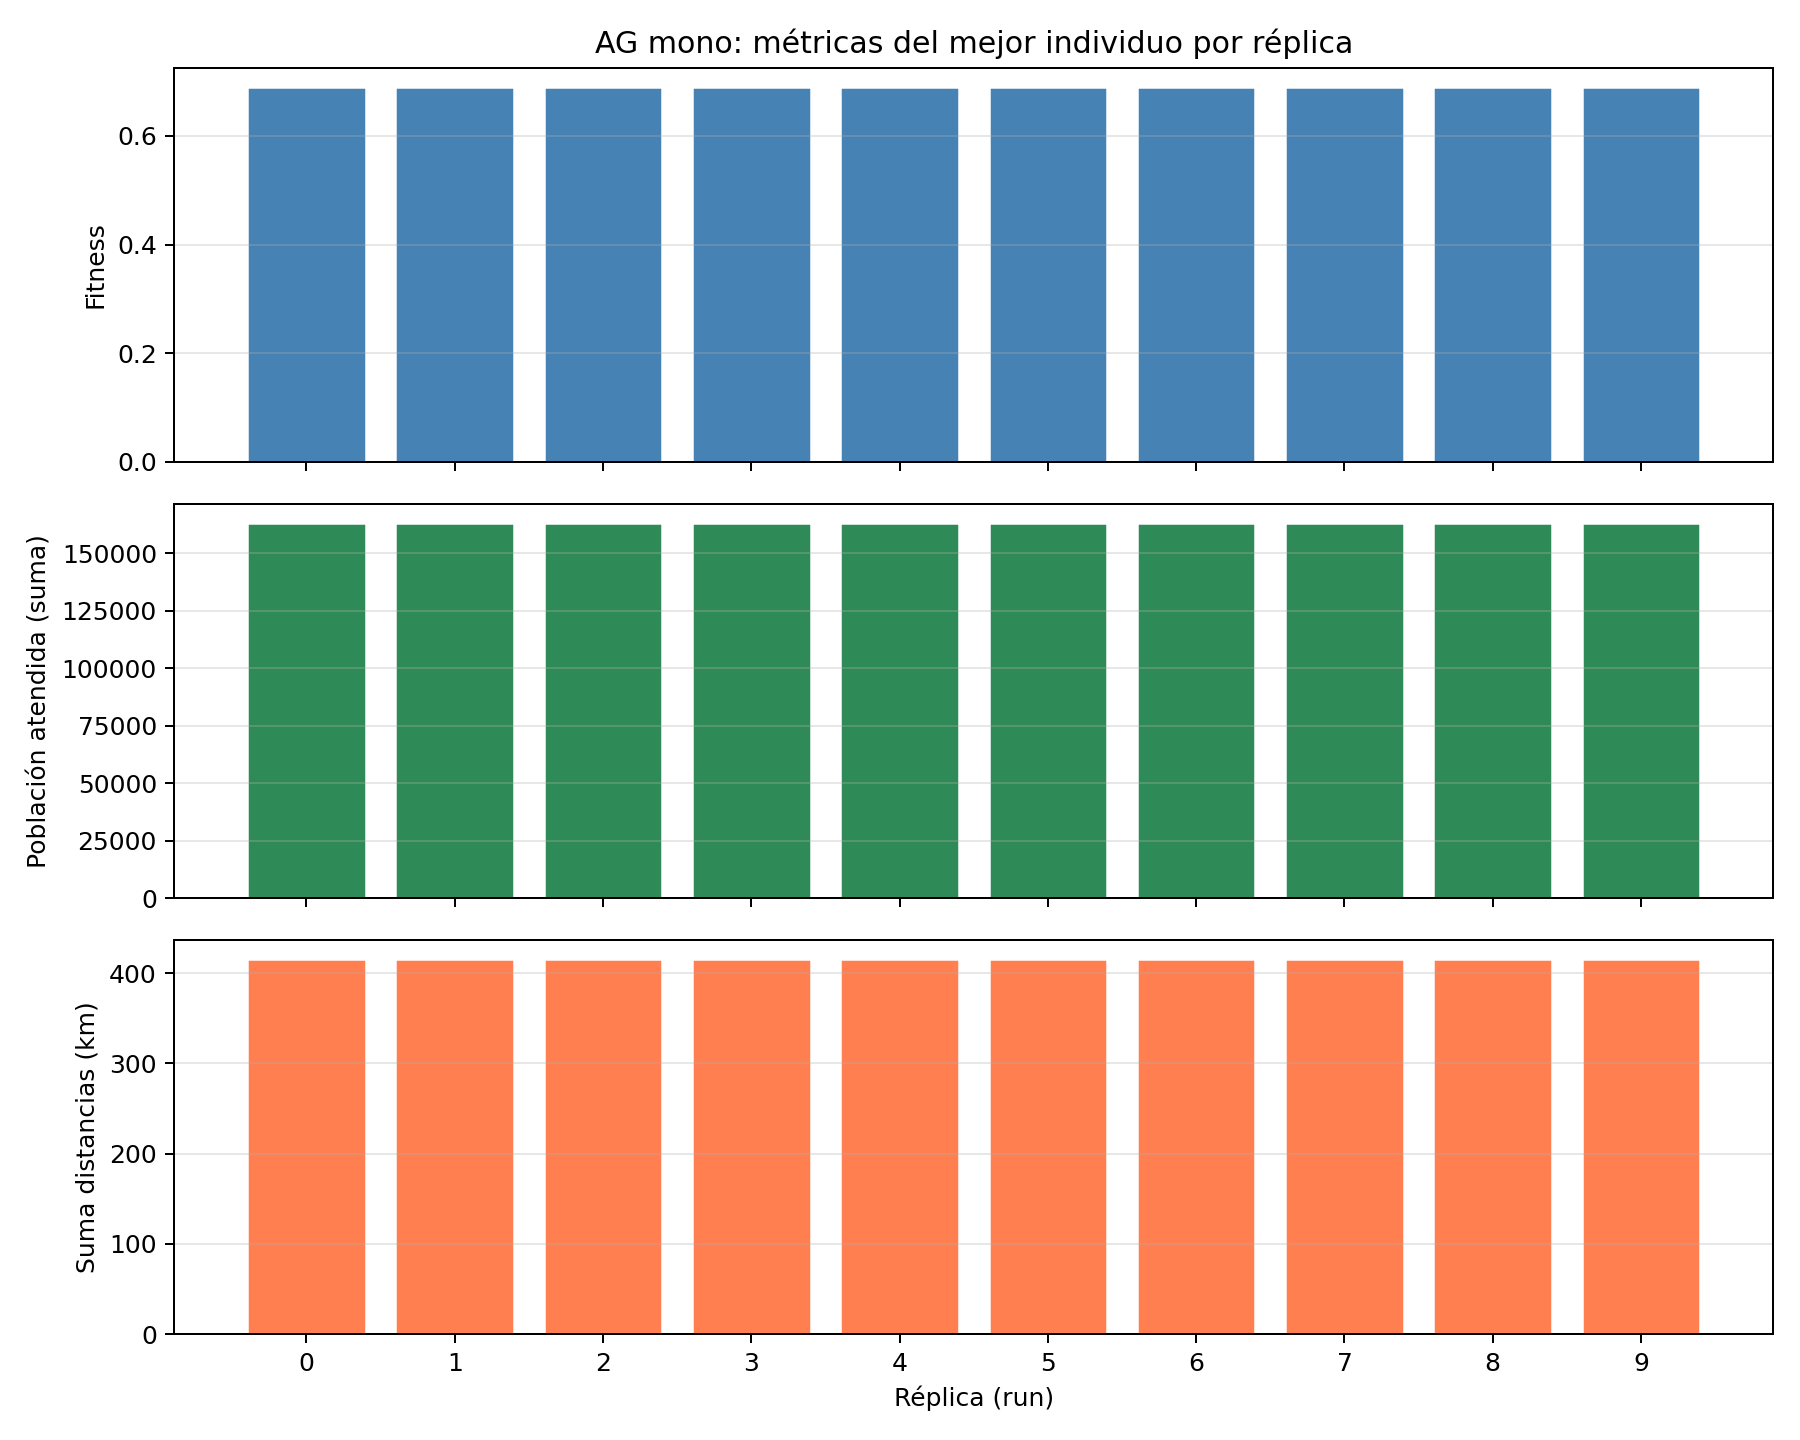

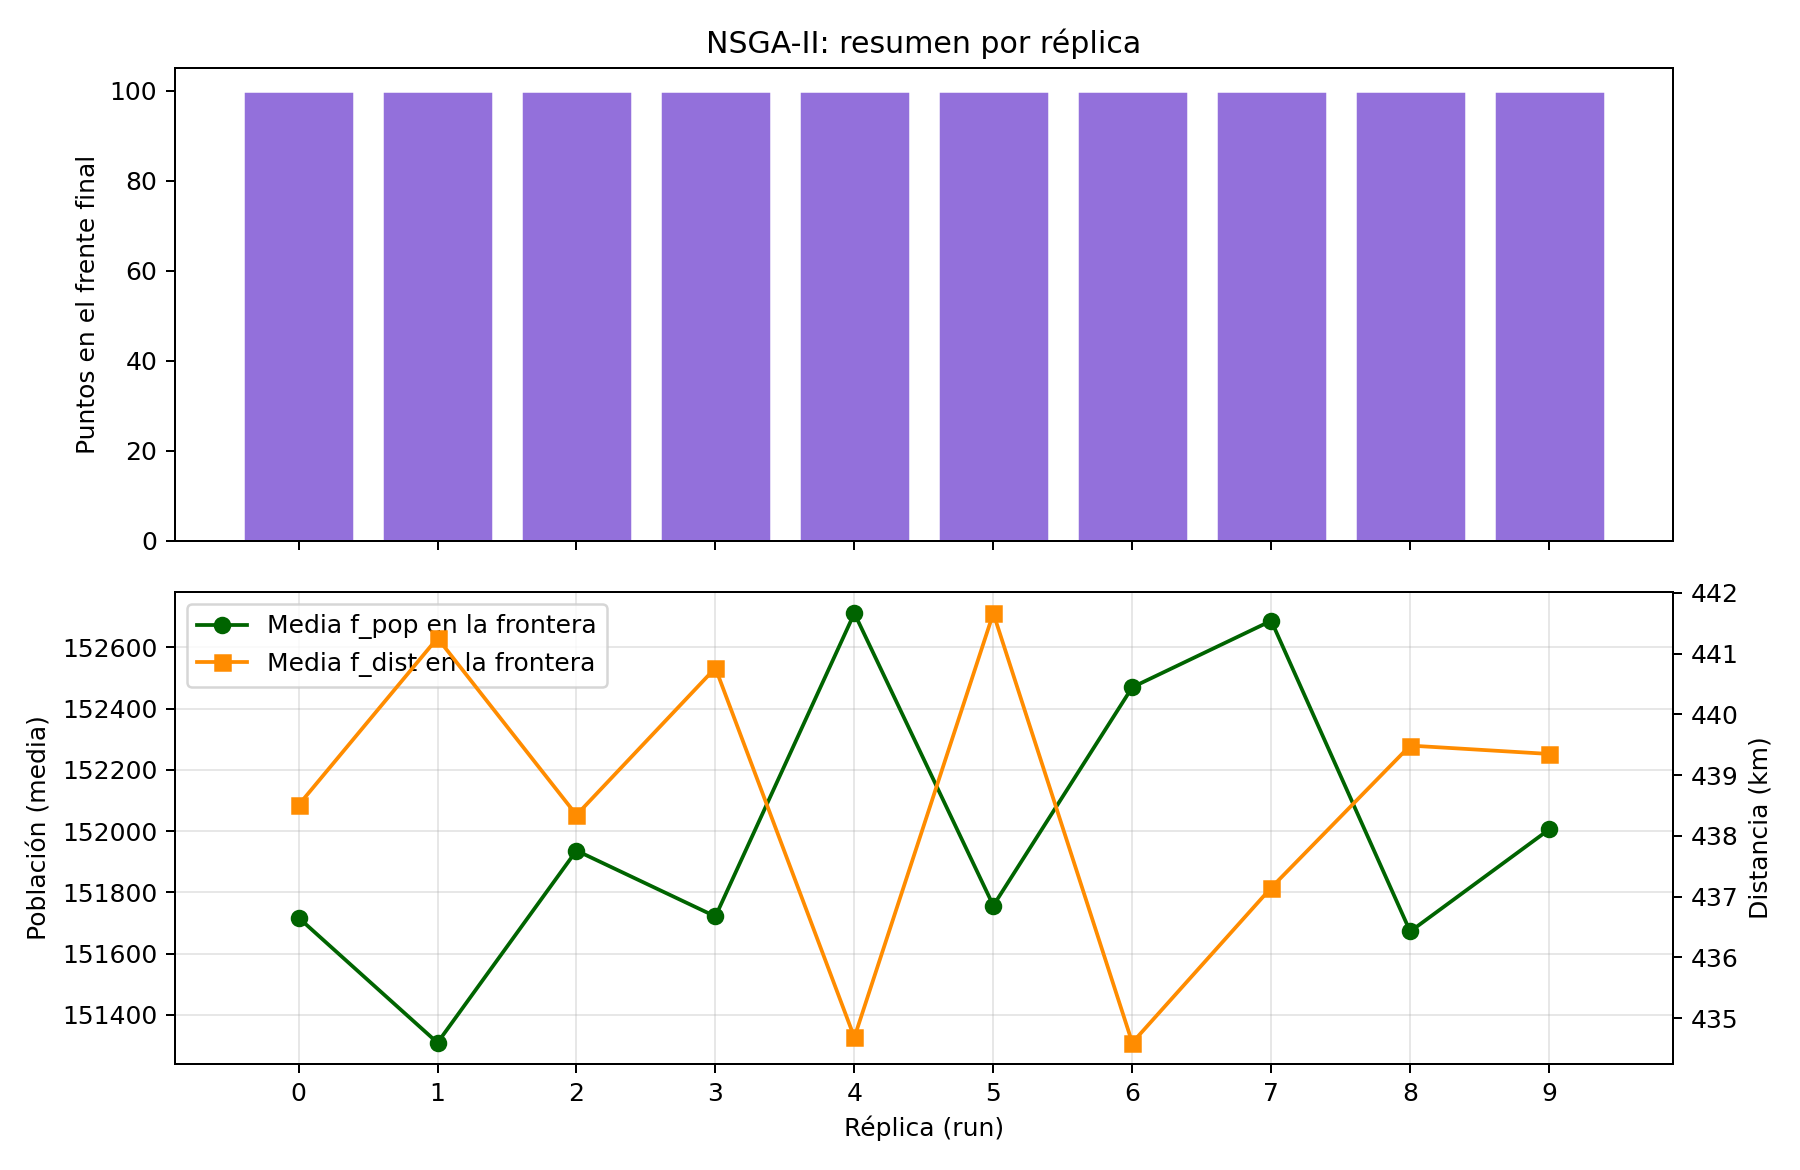

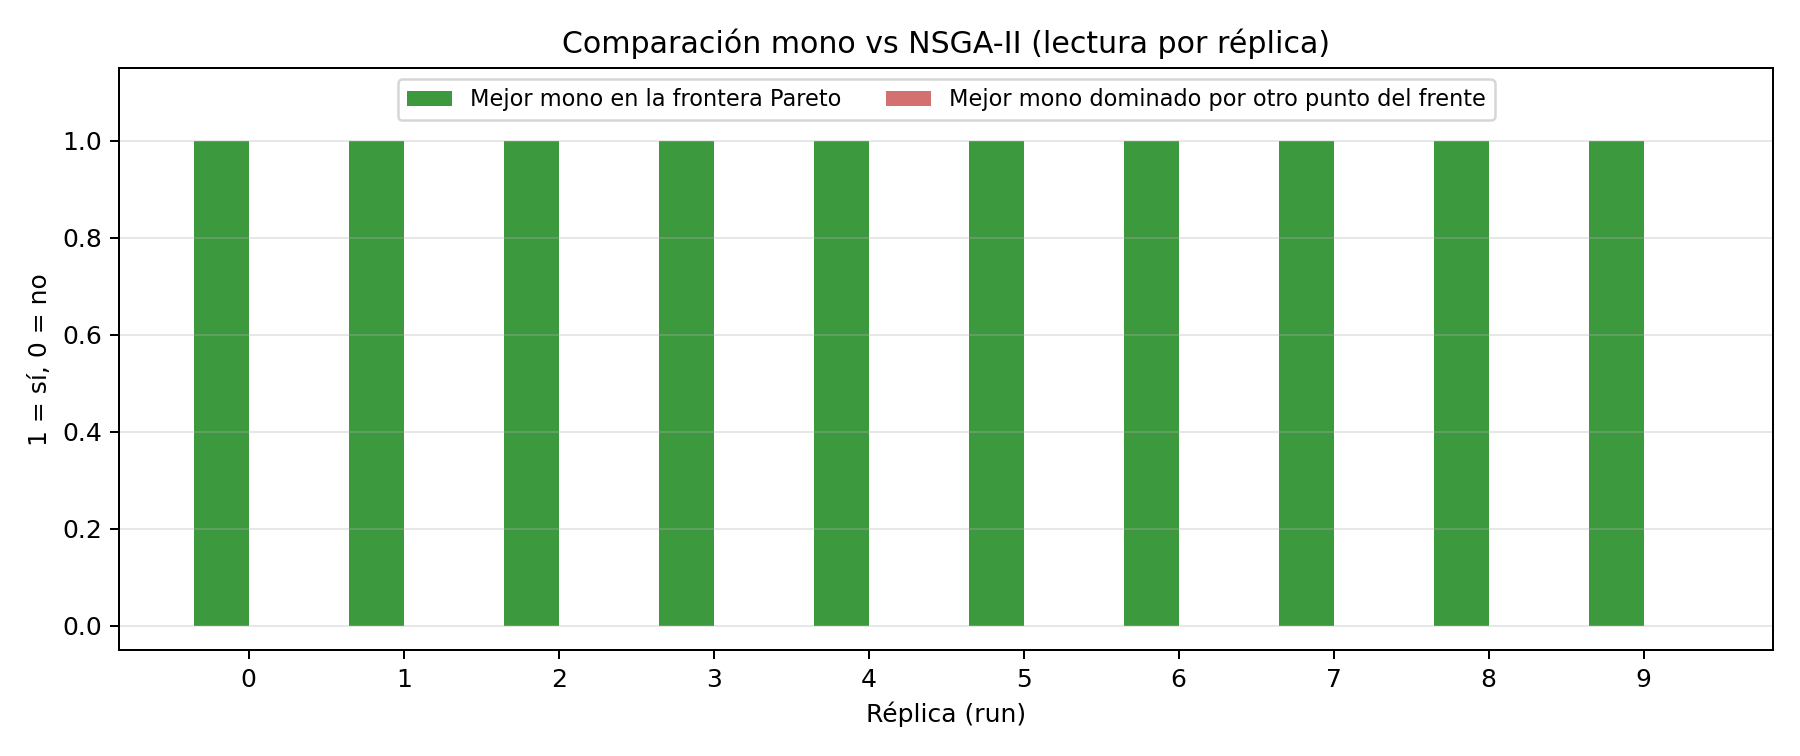

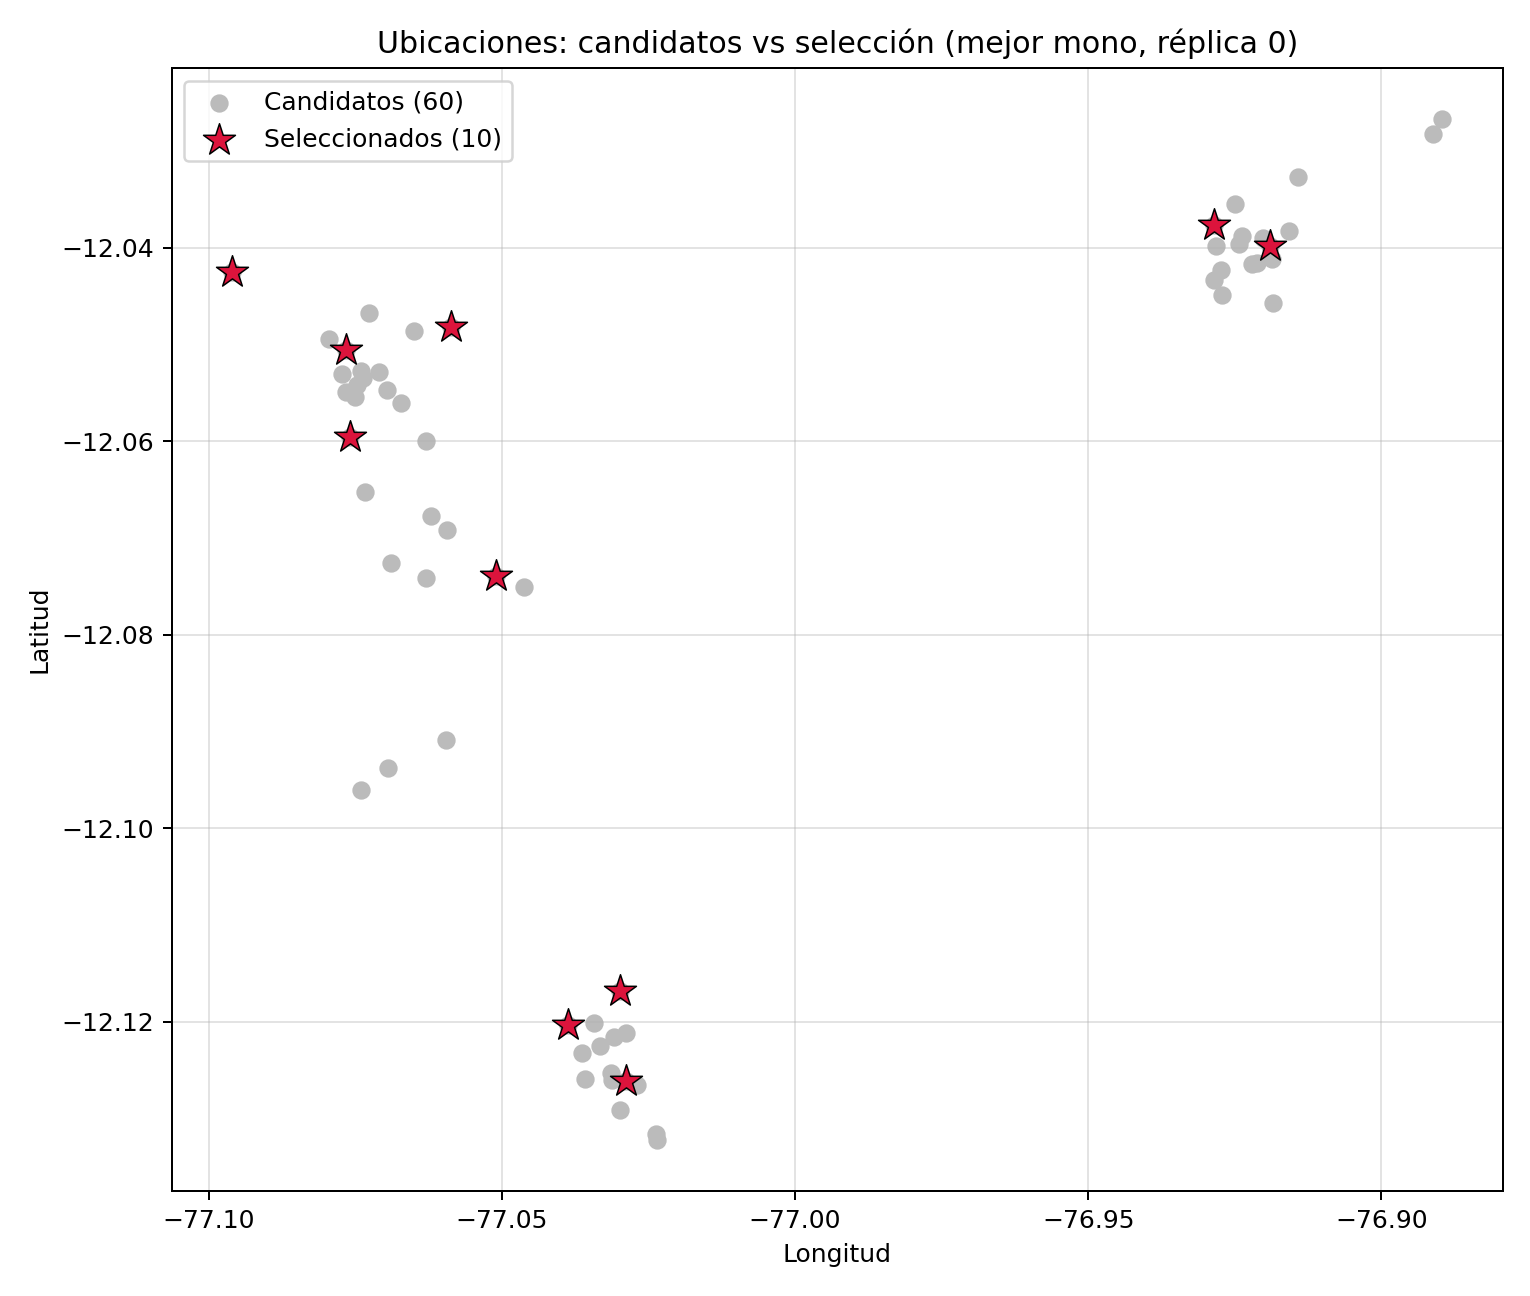

#### Convergencia y frentes de Pareto (ya existentes)

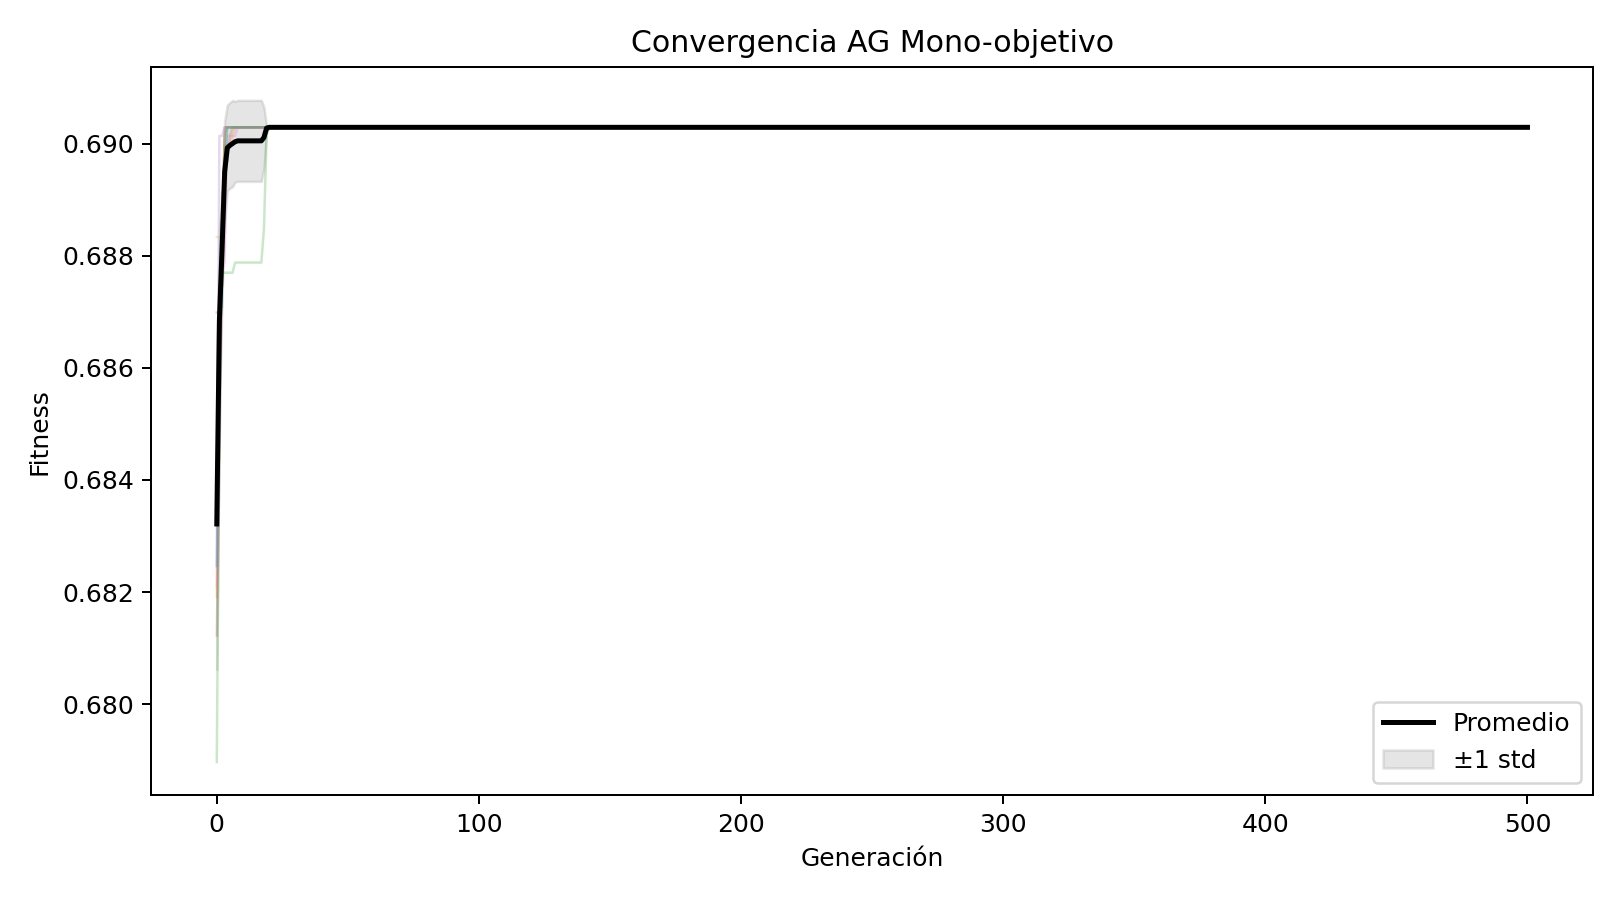

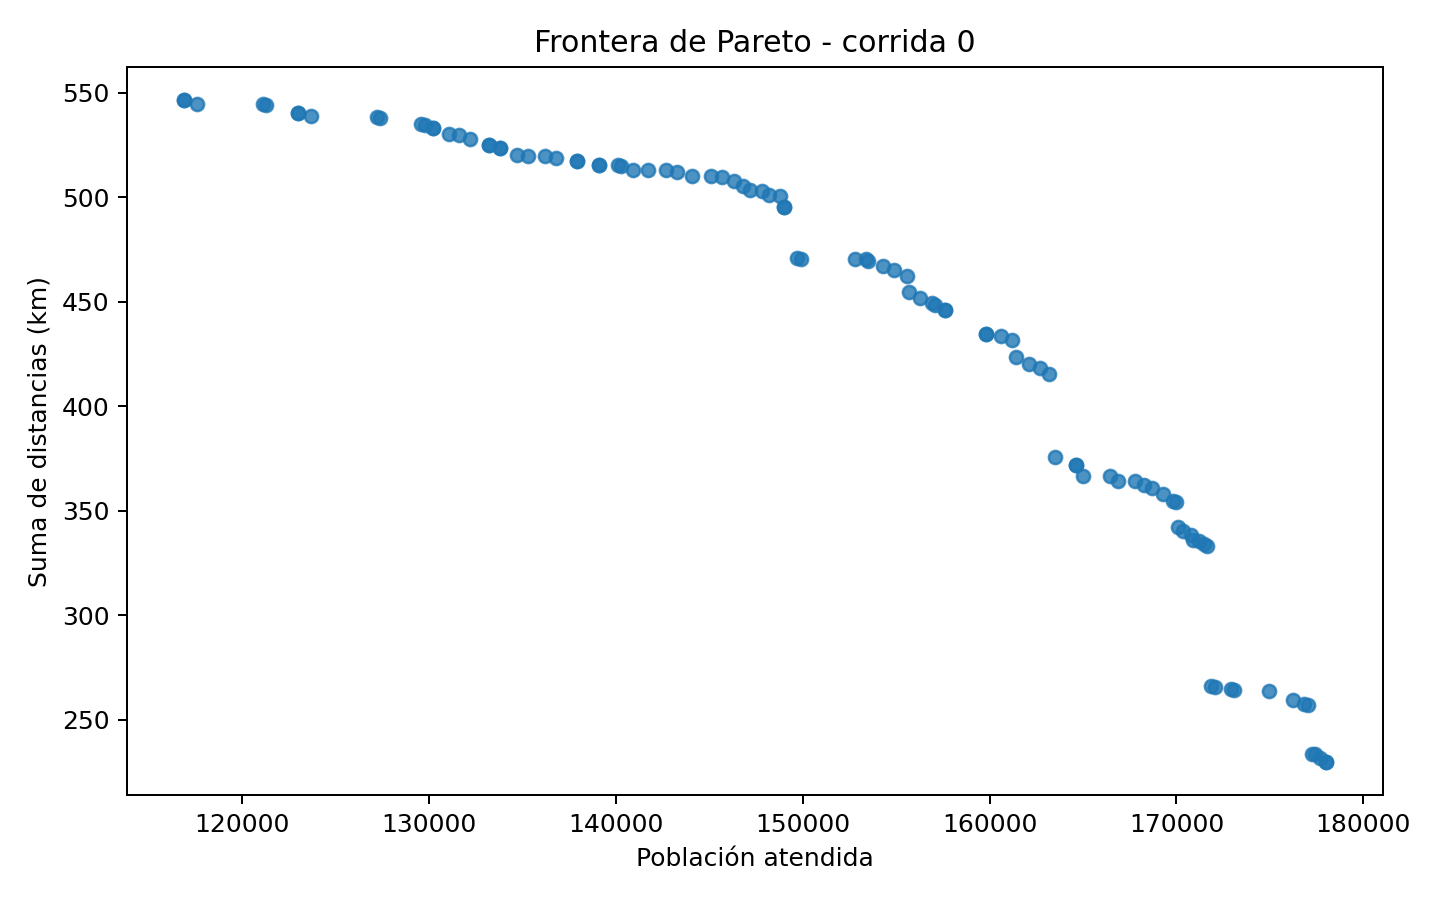

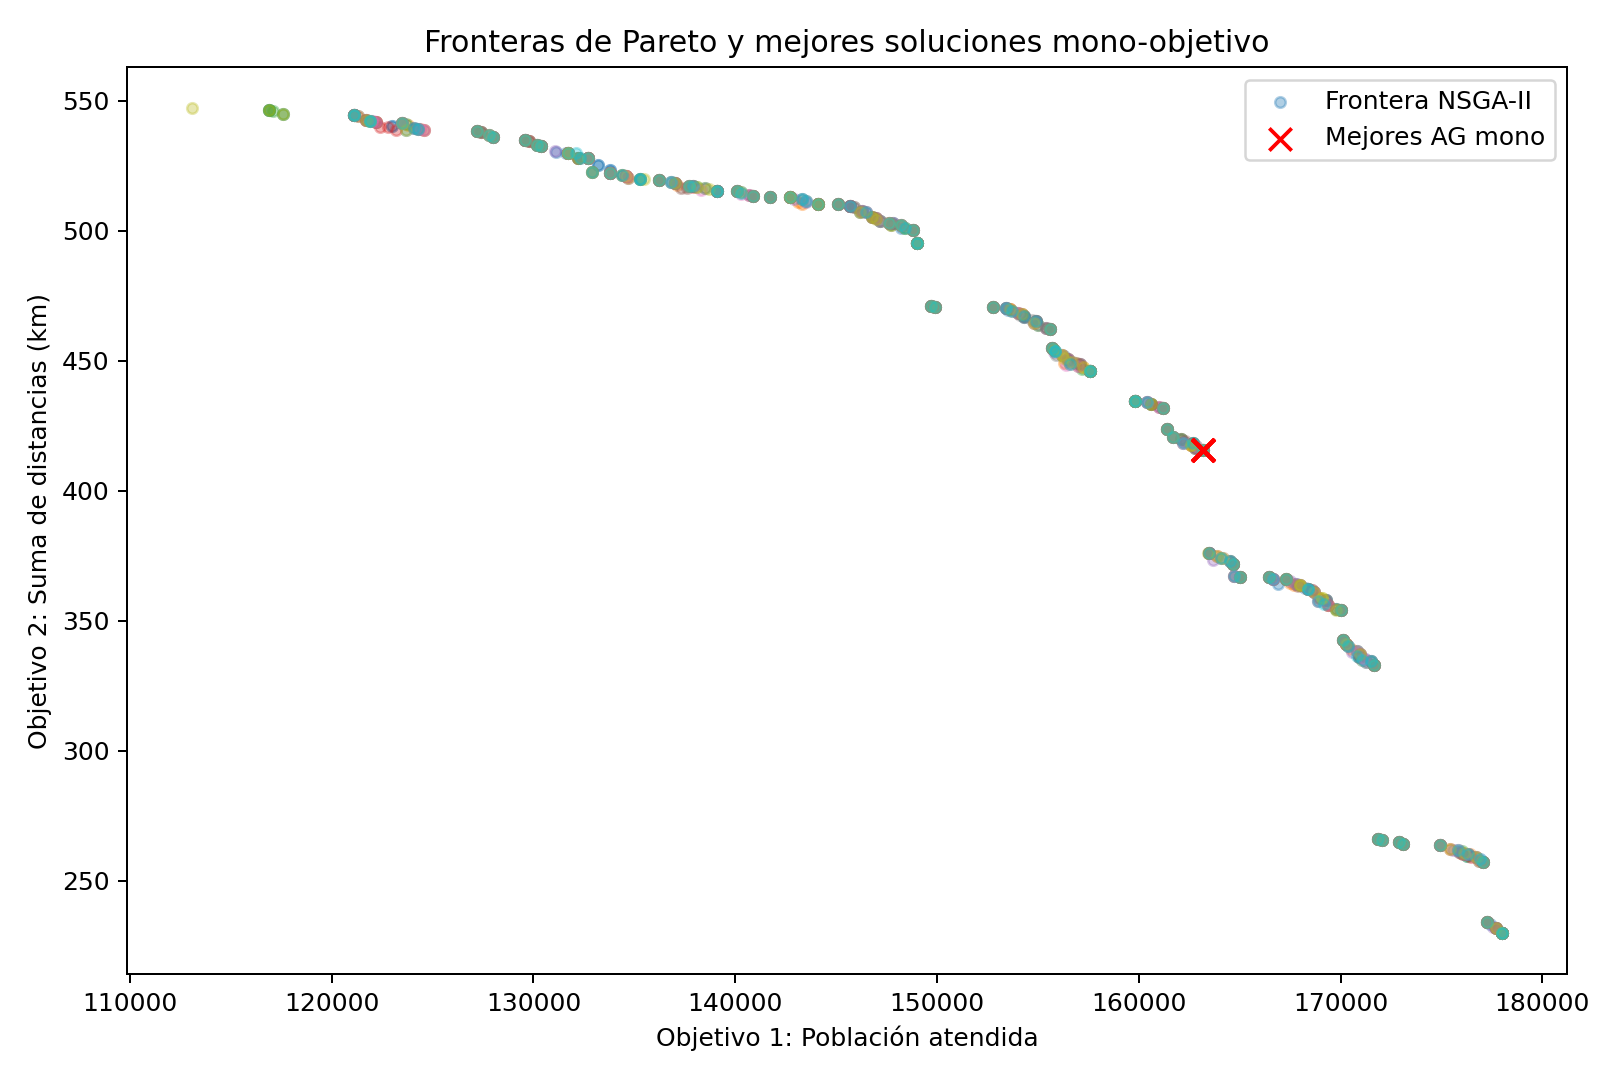

In [14]:
display(Markdown("#### Figuras explicativas (métricas por réplica, comparación y mapa)"))
display(Image(filename=os.path.join(BASE_DIR, "resultados", "figuras", "mono_metricas_por_replica.png")))
display(Image(filename=os.path.join(BASE_DIR, "resultados", "figuras", "nsga_resumen_por_replica.png")))
display(Image(filename=os.path.join(BASE_DIR, "resultados", "figuras", "comparacion_mono_vs_frantera.png")))
display(Image(filename=os.path.join(BASE_DIR, "resultados", "figuras", "mapa_seleccion_run0.png")))


#### Convergencia y frentes de Pareto (ya existentes)

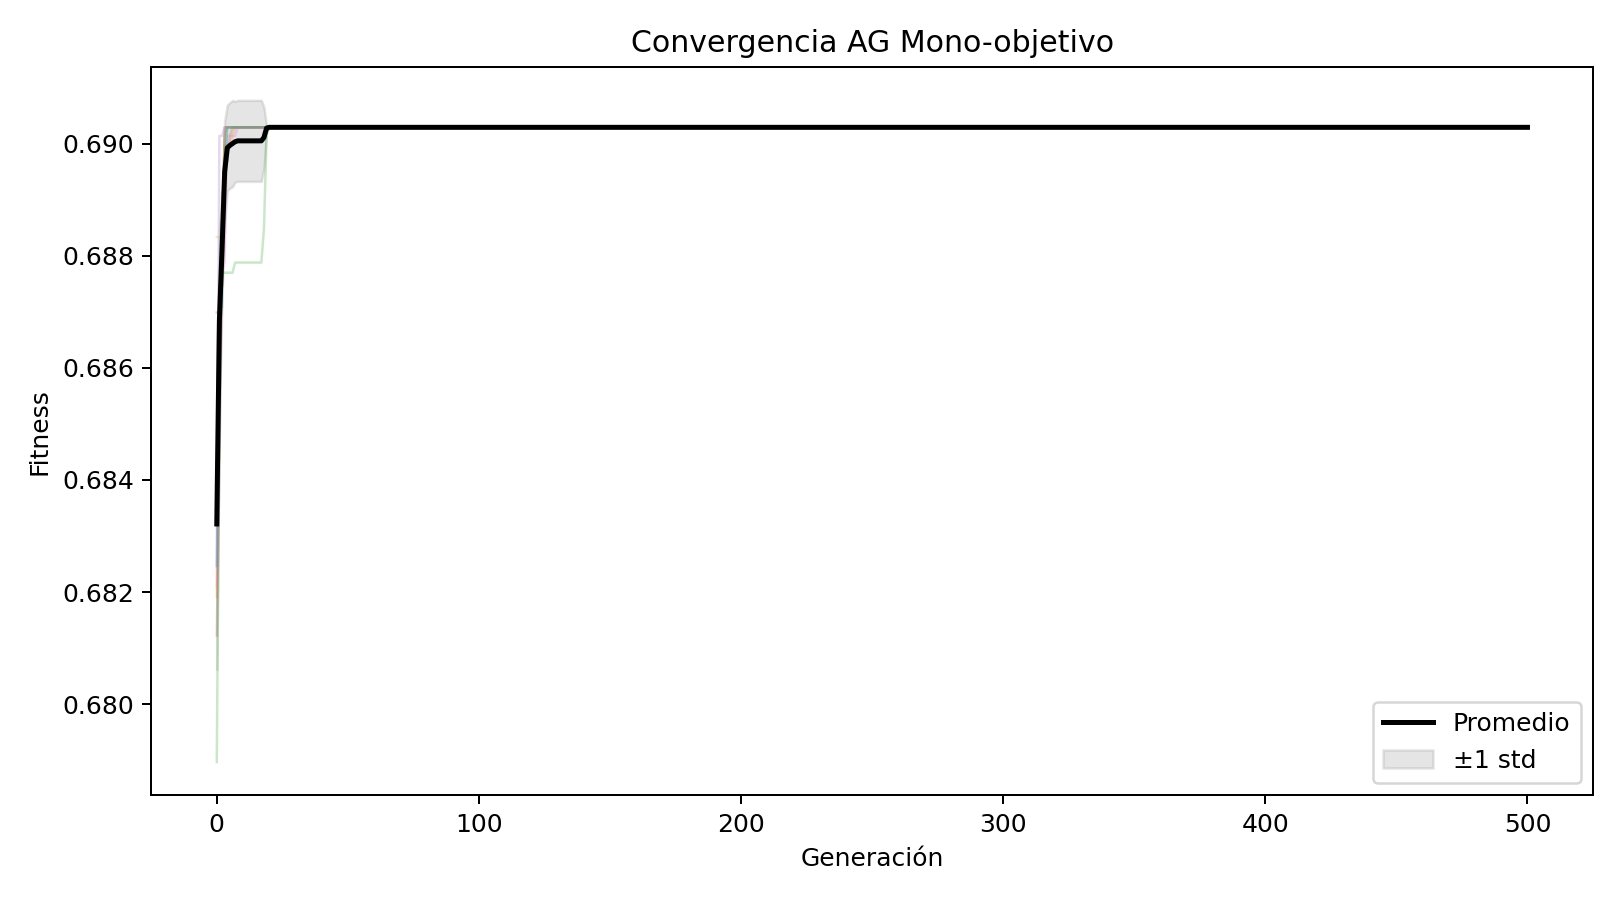

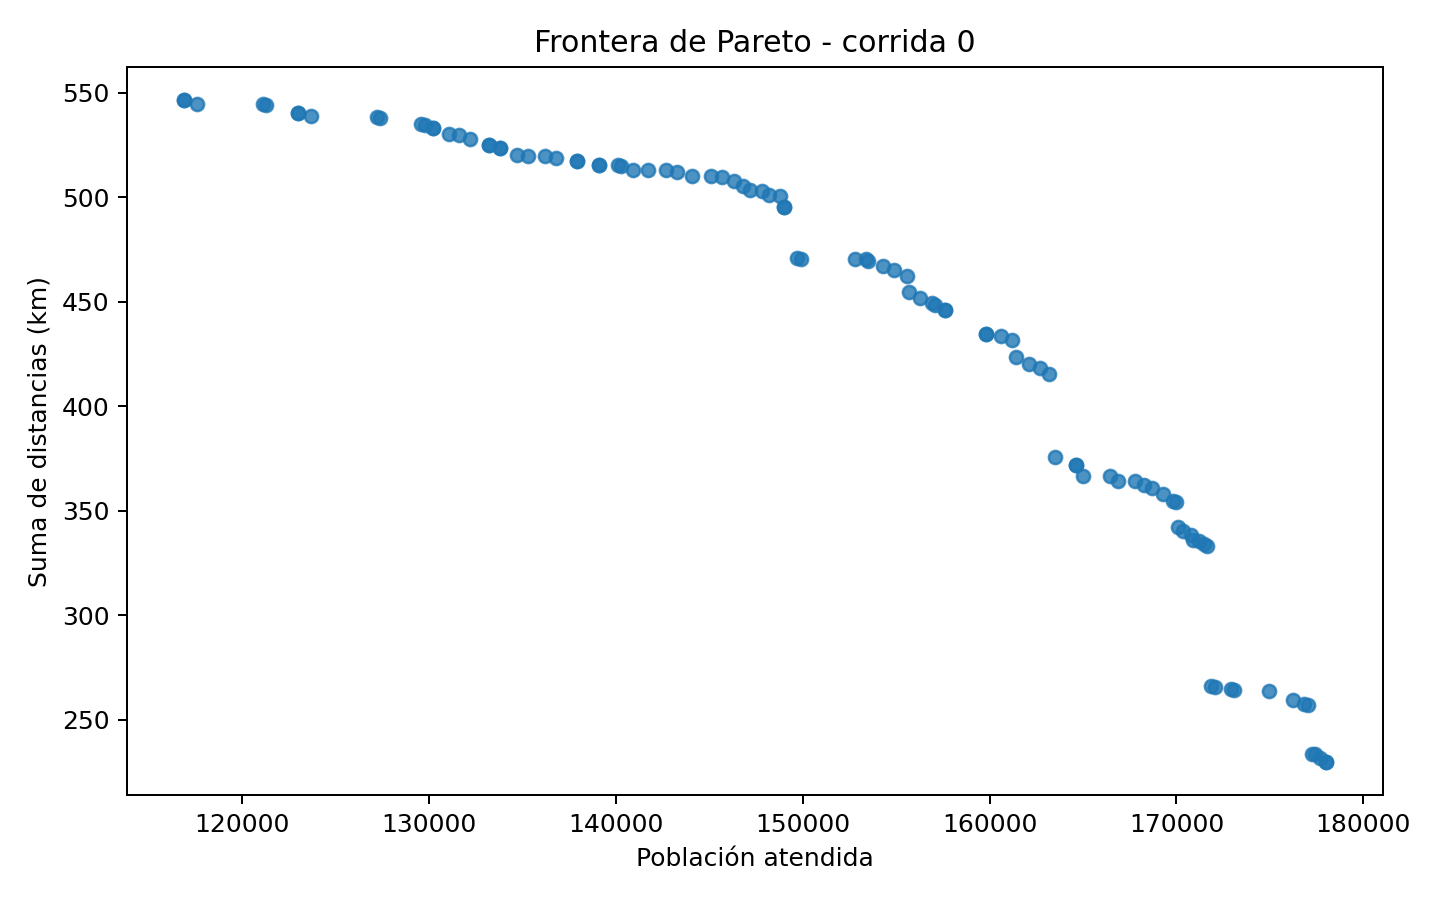

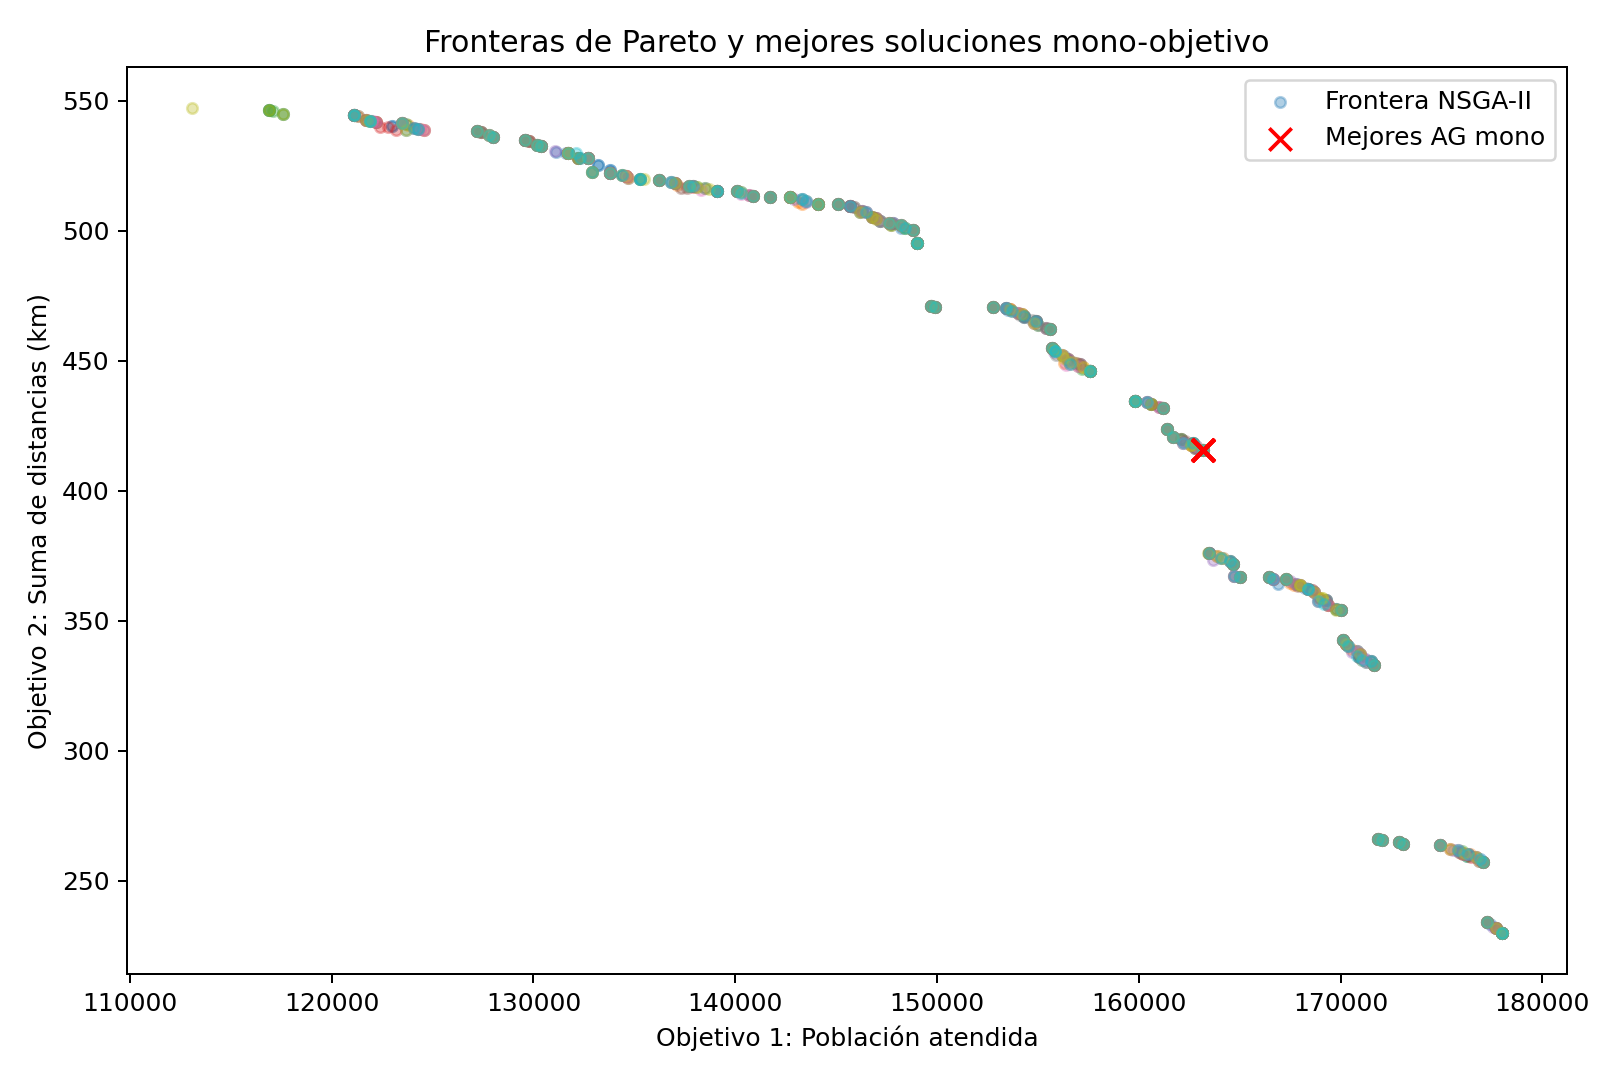

In [19]:
display(Markdown("#### Convergencia y frentes de Pareto (ya existentes)"))
display(Image(filename=os.path.join(BASE_DIR, "resultados", "figuras", "mono_convergencia.png")))
display(Image(filename=os.path.join(BASE_DIR, "resultados", "figuras", "pareto_run0.png")))
display(Image(filename=os.path.join(BASE_DIR, "resultados", "figuras", "pareto_overlay_mono.png")))

## Conclusiones

1. **Problema y enfoque:** Se modeló la elección de 10 supermercados entre 60 candidatos como optimización con restricción de distancia mínima (1 km) y dos criterios: población atendida y dispersión espacial (suma de distancias). La **reparación** de cromosomas garantizó soluciones factibles tras cada operador evolutivo.

2. **AG mono-objetivo:** El fitness ponderado (`alpha`, `beta`) permitió obtener una **solución de compromiso** estable entre réplicas. En las corridas experimentales, el mejor individuo mono mostró **alta repetibilidad** (mismas métricas entre semillas), lo que sugiere un paisaje de búsqueda con un atractivo fuerte bajo esta parametrización.

3. **NSGA-II:** El algoritmo multiobjetivo entregó un **frente de Pareto** con múltiples alternativas no dominadas, visibilizando el trade-off población–distancia. Esto es útil para **decisión gerencial**: no solo un único óptimo escalar, sino un conjunto de opciones según prioridades.

4. **Mono vs Pareto:** En todas las réplicas evaluadas, el mejor individuo del AG mono **pertenece al frente** de NSGA-II y **no queda dominado** por otro punto del frente; es decir, es **Pareto-eficiente** en el sentido bi-objetivo. Aun así, existen puntos en el frente con mayor población o mayor dispersión que el mono, lo que ilustra el valor del enfoque multiobjetivo para explorar el espacio de compromisos.

5. **Visualización:** Las figuras de convergencia, frentes, métricas por réplica, comparación 0/1 y el mapa lat–lon **refuerzan la interpretación** de los CSV y vinculan resultados numéricos con la distribución geográfica en Lima.

6. **Trabajo futuro sugerido:** probar sensibilidad de pesos `alpha`/`beta`, incorporar costos o cobertura sin solapamiento, y validar con otros tamaños de población o número de generaciones.
